# Introduction

Do higher film budgets lead to more box office revenue? Let's find out if there's a relationship using the movie budgets and financial performance data that I've scraped from [the-numbers.com](https://www.the-numbers.com/movie/budgets) on **May 1st, 2018**.

<img src=https://i.imgur.com/kq7hrEh.png>

# Import Statements

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Read the Data

In [4]:
data = pd.read_csv('cost_revenue_dirty.csv')

# Explore and Clean the Data

**Challenge**: Answer these questions about the dataset:
1. How many rows and columns does the dataset contain?
2. Are there any NaN values present?
3. Are there any duplicate rows?
4. What are the data types of the columns?

In [5]:
print(f"Rows: {data.shape[0]} and columns: {data.shape[1]}")


Rows: 5391 and columns: 6


In [6]:
print(f"Any NaN values? : {data.isna().values.any()}")

Any NaN values? : False


In [7]:
print(f"Any duplicated values? : {data.duplicated().values.any()}")

Any duplicated values? : False


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Rank                   5391 non-null   int64 
 1   Release_Date           5391 non-null   object
 2   Movie_Title            5391 non-null   object
 3   USD_Production_Budget  5391 non-null   object
 4   USD_Worldwide_Gross    5391 non-null   object
 5   USD_Domestic_Gross     5391 non-null   object
dtypes: int64(1), object(5)
memory usage: 252.8+ KB


### Data Type Conversions

**Challenge**: Convert the `USD_Production_Budget`, `USD_Worldwide_Gross`, and `USD_Domestic_Gross` columns to a numeric format by removing `$` signs and `,`.
<br>
<br>
Note that *domestic* in this context refers to the United States.

In [9]:
data.USD_Production_Budget=data.USD_Production_Budget.astype(str).str.replace('$','').str.replace(',','')
data.USD_Worldwide_Gross=data.USD_Worldwide_Gross.astype(str).str.replace('$','').str.replace(',','')
data.USD_Domestic_Gross=data.USD_Domestic_Gross.astype(str).str.replace('$','').str.replace(',','')

data.USD_Production_Budget=pd.to_numeric(data.USD_Production_Budget)
data.USD_Worldwide_Gross=pd.to_numeric(data.USD_Worldwide_Gross)
data.USD_Domestic_Gross=pd.to_numeric(data.USD_Domestic_Gross)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Rank                   5391 non-null   int64 
 1   Release_Date           5391 non-null   object
 2   Movie_Title            5391 non-null   object
 3   USD_Production_Budget  5391 non-null   int64 
 4   USD_Worldwide_Gross    5391 non-null   int64 
 5   USD_Domestic_Gross     5391 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 252.8+ KB


**Challenge**: Convert the `Release_Date` column to a Pandas Datetime type.

In [11]:
data.Release_Date=pd.to_datetime(data.Release_Date)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Rank                   5391 non-null   int64         
 1   Release_Date           5391 non-null   datetime64[ns]
 2   Movie_Title            5391 non-null   object        
 3   USD_Production_Budget  5391 non-null   int64         
 4   USD_Worldwide_Gross    5391 non-null   int64         
 5   USD_Domestic_Gross     5391 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 252.8+ KB


### Descriptive Statistics

**Challenge**:

1. What is the average production budget of the films in the data set?
2. What is the average worldwide gross revenue of films?
3. What were the minimums for worldwide and domestic revenue?
4. Are the bottom 25% of films actually profitable or do they lose money?
5. What are the highest production budget and highest worldwide gross revenue of any film?
6. How much revenue did the lowest and highest budget films make?

In [12]:
print(f"Average production budget of films(in dollars): {data.USD_Production_Budget.mean()}")
print(f"Average worldwide gross revenue of films(in dollars): {data.USD_Worldwide_Gross.mean()}")
print(f"Minimum worldwide revenue(in dollars): {data.USD_Worldwide_Gross.min()}")
print(f"Minimum domestic revenue(in dollars): {data.USD_Domestic_Gross.min()}")


Average production budget of films(in dollars): 31113737.57837136
Average worldwide gross revenue of films(in dollars): 88855421.96271564
Minimum worldwide revenue(in dollars): 0
Minimum domestic revenue(in dollars): 0


In [13]:
data.describe()

,Rank,Release_Date,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
count,"5,391.00",5391,"5,391.00","5,391.00","5,391.00"
mean,"2,696.00",2003-09-19 15:02:02.203672704,"31,113,737.58","88,855,421.96","41,235,519.44"
min,1.00,1915-08-02 00:00:00,"1,100.00",0.00,0.00
25%,"1,348.50",1999-12-02 12:00:00,"5,000,000.00","3,865,206.00","1,330,901.50"
50%,"2,696.00",2006-06-23 00:00:00,"17,000,000.00","27,450,453.00","17,192,205.00"
75%,"4,043.50",2011-11-23 00:00:00,"40,000,000.00","96,454,455.00","52,343,687.00"
max,"5,391.00",2020-12-31 00:00:00,"425,000,000.00","2,783,918,982.00","936,662,225.00"
std,"1,556.39",NaN,"40,523,796.88","168,457,757.00","66,029,346.27"


In [14]:
print(f"Highest production budget:{data.USD_Production_Budget.max()}")
print(f"Highest Worldwide gross revenue: {data.USD_Worldwide_Gross.max()}")

Highest production budget:425000000
Highest Worldwide gross revenue: 2783918982


In [15]:
print(f"Revenue made by the lowest budget film: {data.USD_Worldwide_Gross[data.USD_Production_Budget.idxmin()]}")
print(f"Revenue made by the highest budget film: {data.USD_Worldwide_Gross[data.USD_Production_Budget.idxmax()]}")

Revenue made by the lowest budget film: 181041
Revenue made by the highest budget film: 2783918982


From the above data, the bottom 25% of films have average production cost of 5 million dollars but they only make around 3.9 million so its a loss

# Investigating the Zero Revenue Films

**Challenge** How many films grossed $0 domestically (i.e., in the United States)? What were the highest budget films that grossed nothing?

In [16]:
print(f"Number of films that grossed $0 in the U.S: {data[data.USD_Domestic_Gross==0].shape[0]}")

Number of films that grossed $0 in the U.S: 512


In [17]:
print("Highest budget films that grossed nothing:")
data[data.USD_Domestic_Gross==0].sort_values('USD_Production_Budget',ascending=False)

Highest budget films that grossed nothing:


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5090,556,2015-12-31,"Don Gato, el inicio de la pandilla",80000000,4547660,0
...,...,...,...,...,...,...
4787,5371,2014-12-31,Stories of Our Lives,15000,0,0
3056,5374,2007-12-31,Tin Can Man,12000,0,0
4907,5381,2015-05-19,Family Motocross,10000,0,0
5006,5389,2015-09-29,Signed Sealed Delivered,5000,0,0


**Challenge**: How many films grossed $0 worldwide? What are the highest budget films that had no revenue internationally?

In [18]:
print(f"Number of films that grossed $0: {data[data.USD_Worldwide_Gross==0].shape[0]}")
print(f"Highest busget films that have no revenue internationally:")
data[data.USD_Worldwide_Gross==0].sort_values('USD_Production_Budget',ascending=False)

Number of films that grossed $0: 357
Highest busget films that have no revenue internationally:


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5058,880,2015-11-12,The Ridiculous 6,60000000,0,0
...,...,...,...,...,...,...
4787,5371,2014-12-31,Stories of Our Lives,15000,0,0
3056,5374,2007-12-31,Tin Can Man,12000,0,0
4907,5381,2015-05-19,Family Motocross,10000,0,0
5006,5389,2015-09-29,Signed Sealed Delivered,5000,0,0


### Filtering on Multiple Conditions

In [19]:
international_releases=data.loc[(data.USD_Domestic_Gross==0) & (data.USD_Worldwide_Gross!=0)]
international_releases.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
71,4310,1956-02-16,Carousel,3380000,3220,0
1579,5087,2001-02-11,Everything Put Together,500000,7890,0
1744,3695,2001-12-31,The Hole,7500000,10834406,0
2155,4236,2003-12-31,Nothing,4000000,63180,0
2203,2513,2004-03-31,The Touch,20000000,5918742,0


**Challenge**: Use the [`.query()` function](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.query.html) to accomplish the same thing. Create a subset for international releases that had some worldwide gross revenue, but made zero revenue in the United States.

Hint: This time you'll have to use the `and` keyword.

In [20]:
international_releases=data.query("USD_Domestic_Gross == 0 and USD_Worldwide_Gross!=0")
international_releases.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
71,4310,1956-02-16,Carousel,3380000,3220,0
1579,5087,2001-02-11,Everything Put Together,500000,7890,0
1744,3695,2001-12-31,The Hole,7500000,10834406,0
2155,4236,2003-12-31,Nothing,4000000,63180,0
2203,2513,2004-03-31,The Touch,20000000,5918742,0


### Unreleased Films

**Challenge**:
* Identify which films were not released yet as of the time of data collection (May 1st, 2018).
* How many films are included in the dataset that have not yet had a chance to be screened in the box office?
* Create another DataFrame called data_clean that does not include these films.

In [21]:
# Date of Data Collection
scrape_date = pd.Timestamp('2018-5-1')

In [22]:
print(f"Number of films not yet released as of May 1st,2018: {data[data.Release_Date>scrape_date].shape[0]}")
print("Unreleased films:")
data[data.Release_Date>scrape_date]

Number of films not yet released as of May 1st,2018: 7
Unreleased films:


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5386,2950,2018-10-08,Meg,15000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5388,96,2020-12-31,Singularity,175000000,0,0
5389,1119,2020-12-31,Hannibal the Conqueror,50000000,0,0
5390,2517,2020-12-31,"Story of Bonnie and Clyde, The",20000000,0,0


In [23]:
data_clean=data[data.Release_Date<=scrape_date]
data_clean.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,1915-08-02,The Birth of a Nation,110000,11000000,10000000
1,5140,1916-05-09,Intolerance,385907,0,0
2,5230,1916-12-24,"20,000 Leagues Under the Sea",200000,8000000,8000000
3,5299,1920-09-17,Over the Hill to the Poorhouse,100000,3000000,3000000
4,5222,1925-01-01,The Big Parade,245000,22000000,11000000


### Films that Lost Money

**Challenge**:
What is the percentage of films where the production costs exceeded the worldwide gross revenue?

In [24]:
money_losses=data_clean[data_clean.USD_Production_Budget>data_clean.USD_Worldwide_Gross]
percentage=(len(money_losses))/(len(data_clean))*100
print(f"Percentage of films where the production costs exceeded the worldwide gross revenue: {percentage}")

Percentage of films where the production costs exceeded the worldwide gross revenue: 37.27711738484398


# Seaborn for Data Viz: Bubble Charts

In [25]:
import seaborn as sns

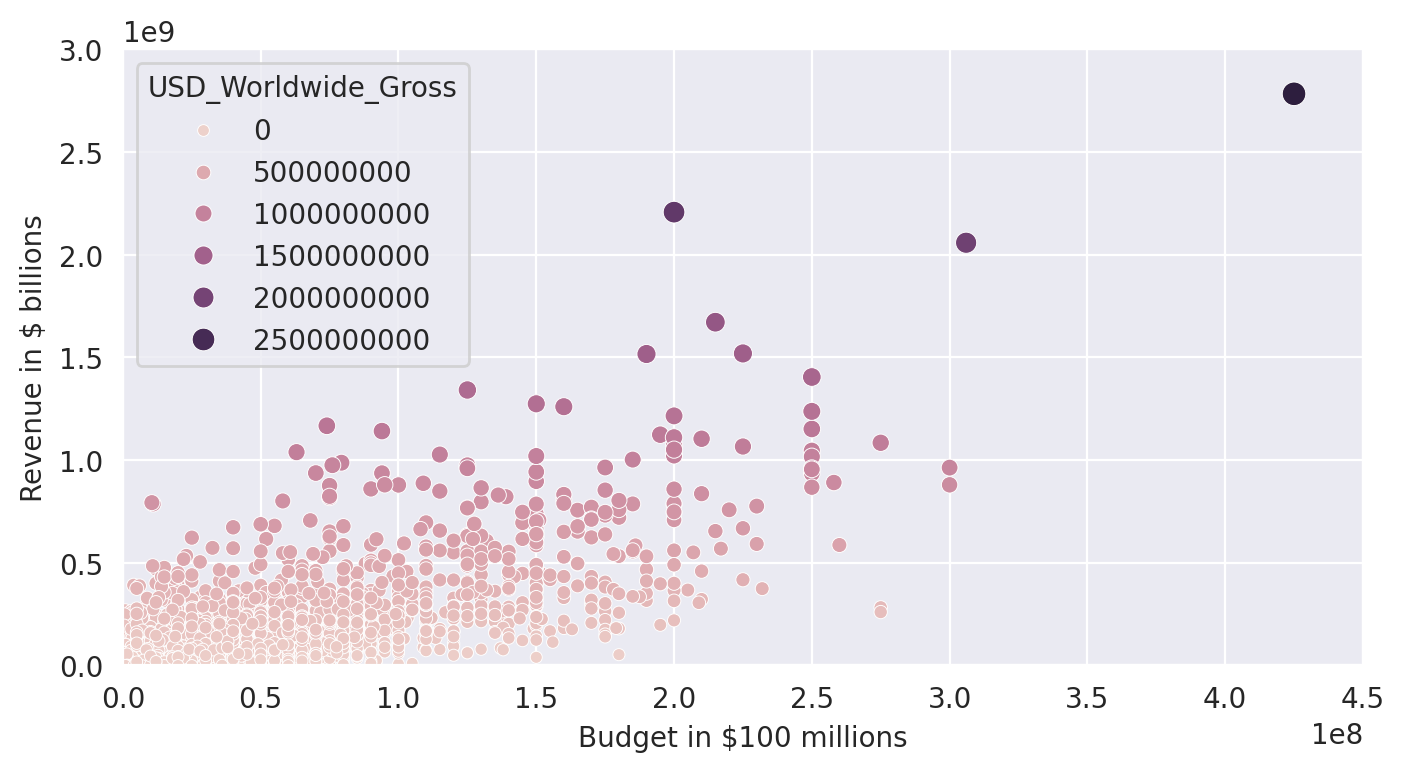

In [33]:
plt.figure(figsize=(8,4),dpi=200)
with sns.axes_style('darkgrid'):
  ax=sns.scatterplot(data=data_clean,
                    x='USD_Production_Budget',
                    y='USD_Worldwide_Gross',
                    hue='USD_Worldwide_Gross',
                    size='USD_Worldwide_Gross')
  ax.set(ylim=(0,3000000000),
        xlim=(0,450000000),
        ylabel='Revenue in $ billions',
        xlabel='Budget in $100 millions')
plt.show()


### Plotting Movie Releases over Time

**Challenge**: Try to create the following Bubble Chart:

<img src=https://i.imgur.com/8fUn9T6.png>



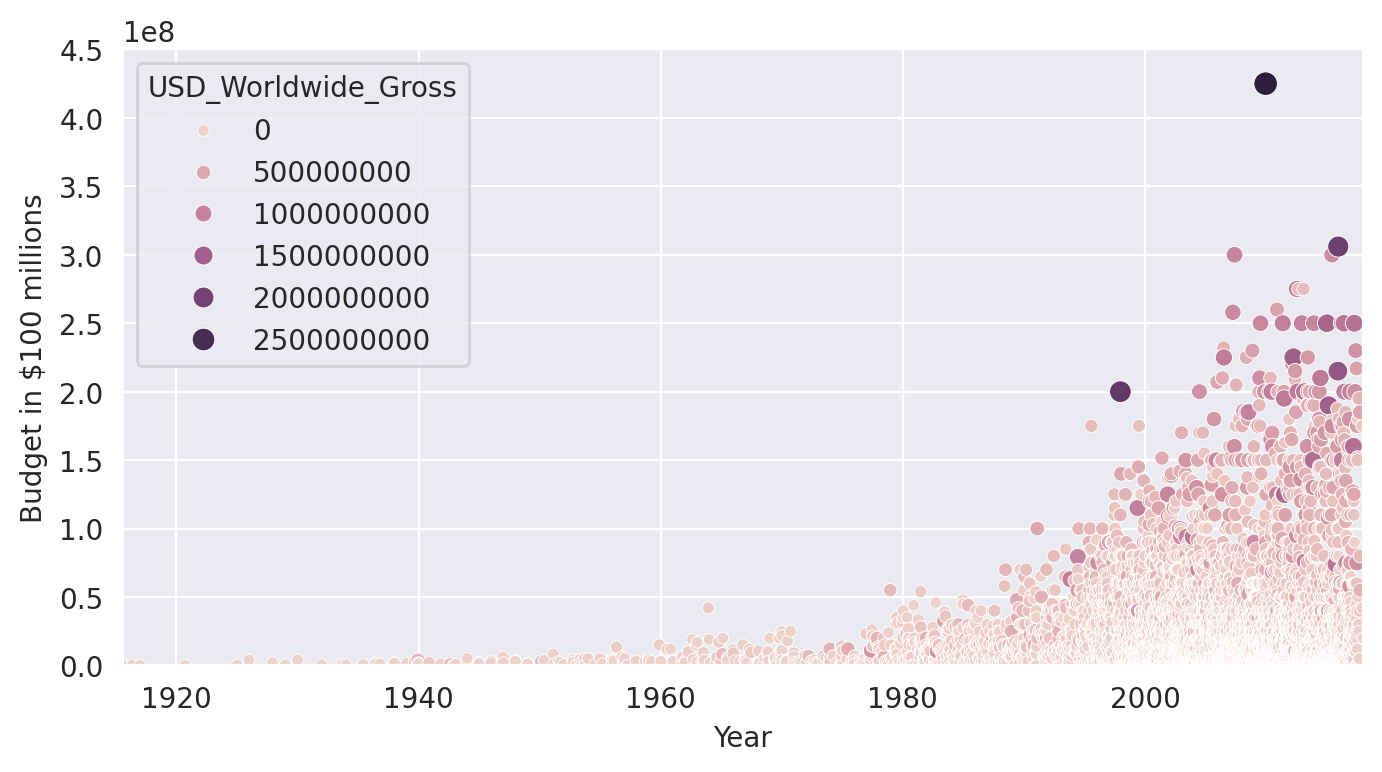

In [37]:
plt.figure(figsize=(8,4),dpi=200)
with sns.axes_style('darkgrid'):
  ax=sns.scatterplot(data=data_clean,
                     x='Release_Date',
                     y='USD_Production_Budget',
                     hue='USD_Worldwide_Gross',
                     size='USD_Worldwide_Gross')
  ax.set(ylim=(0,450000000),
         xlim=(data_clean.Release_Date.min(),data_clean.Release_Date.max()),
         ylabel="Budget in $100 millions",
         xlabel="Year")
plt.show()

# Converting Years to Decades Trick

**Challenge**: Create a column in `data_clean` that has the decade of the release.

<img src=https://i.imgur.com/0VEfagw.png width=650>

Here's how:
1. Create a [`DatetimeIndex` object](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DatetimeIndex.html) from the Release_Date column.
2. Grab all the years from the `DatetimeIndex` object using the `.year` property.
<img src=https://i.imgur.com/5m06Ach.png width=650>
3. Use floor division `//` to convert the year data to the decades of the films.
4. Add the decades as a `Decade` column to the `data_clean` DataFrame.

In [38]:
dt_index_obj=pd.DatetimeIndex(data_clean.Release_Date)
years=dt_index_obj.year
decades=(years//10)*10
data_clean['Decade']=decades
data_clean.head()

/tmp/ipykernel_3816/2610722285.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['Decade']=decades


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Decade
0,5293,1915-08-02,The Birth of a Nation,110000,11000000,10000000,1910
1,5140,1916-05-09,Intolerance,385907,0,0,1910
2,5230,1916-12-24,"20,000 Leagues Under the Sea",200000,8000000,8000000,1910
3,5299,1920-09-17,Over the Hill to the Poorhouse,100000,3000000,3000000,1920
4,5222,1925-01-01,The Big Parade,245000,22000000,11000000,1920


### Separate the "old" (before 1969) and "New" (1970s onwards) Films

**Challenge**: Create two new DataFrames: `old_films` and `new_films`
* `old_films` should include all the films before 1969 (up to and including 1969)
* `new_films` should include all the films from 1970 onwards
* How many films were released prior to 1970?
* What was the most expensive film made prior to 1970?

In [43]:
old_films=data_clean[data_clean.Decade<1970]
new_films=data_clean[data_clean.Decade>=1970]
print(f"Number of films released prior to 1970: {old_films.shape[0]}")
print(f"The most expensive film made prior to 1970: ")
print(f"{old_films.sort_values('USD_Production_Budget',ascending=False).head()}")

Number of films released prior to 1970: 153
The most expensive film made prior to 1970: 
     Rank Release_Date                   Movie_Title  USD_Production_Budget  \
109  1253   1963-12-06                     Cleopatra               42000000   
150  2175   1969-12-16                  Hello, Dolly               24000000   
118  2425   1965-02-15  The Greatest Story Ever Told               20000000   
143  2465   1969-01-01                 Sweet Charity               20000000   
148  2375   1969-10-15              Paint Your Wagon               20000000   

     USD_Worldwide_Gross  USD_Domestic_Gross  Decade  
109             71000000            57000000    1960  
150             33208099            33208099    1960  
118             15473333            15473333    1960  
143              8000000             8000000    1960  
148             31678778            31678778    1960  


# Seaborn Regression Plots

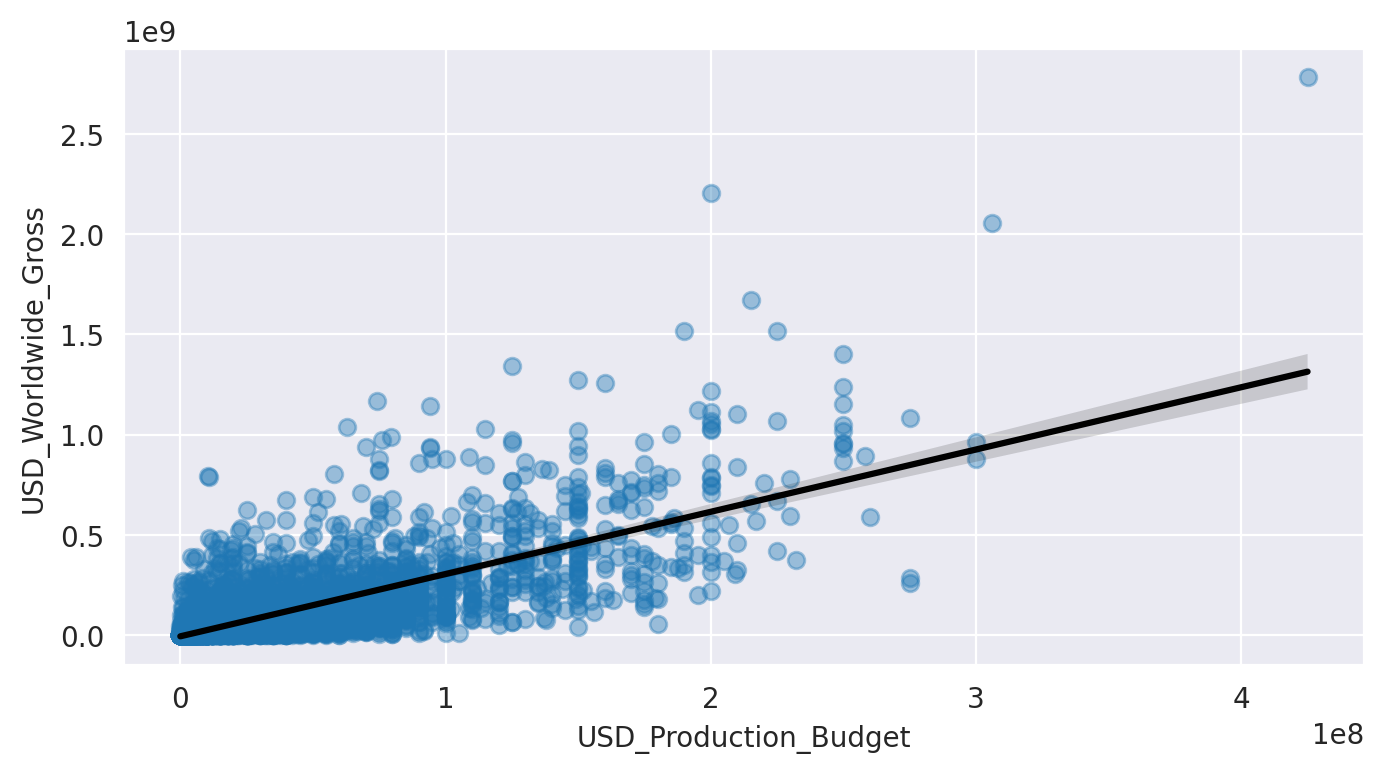

In [45]:
plt.figure(figsize=(8,4),dpi=200)
with sns.axes_style('darkgrid'):
  ax=sns.regplot(data=data_clean,
                 x='USD_Production_Budget',
                 y='USD_Worldwide_Gross',
                 scatter_kws={'alpha':0.4},
                 line_kws={'color':'black'})
plt.show()

**Challenge**: Use Seaborn's `.regplot()` to show the scatter plot and linear regression line against the `new_films`.
<br>
<br>
Style the chart

* Put the chart on a `'darkgrid'`.
* Set limits on the axes so that they don't show negative values.
* Label the axes on the plot "Revenue in \$ billions" and "Budget in \$100 millions".
* Provide HEX colour codes for the plot and the regression line. Make the dots dark blue (#2f4b7c) and the line orange (#ff7c43).

Interpret the chart

* Do our data points for the new films align better or worse with the linear regression than for our older films?
* Roughly how much would a film with a budget of $150 million make according to the regression line?

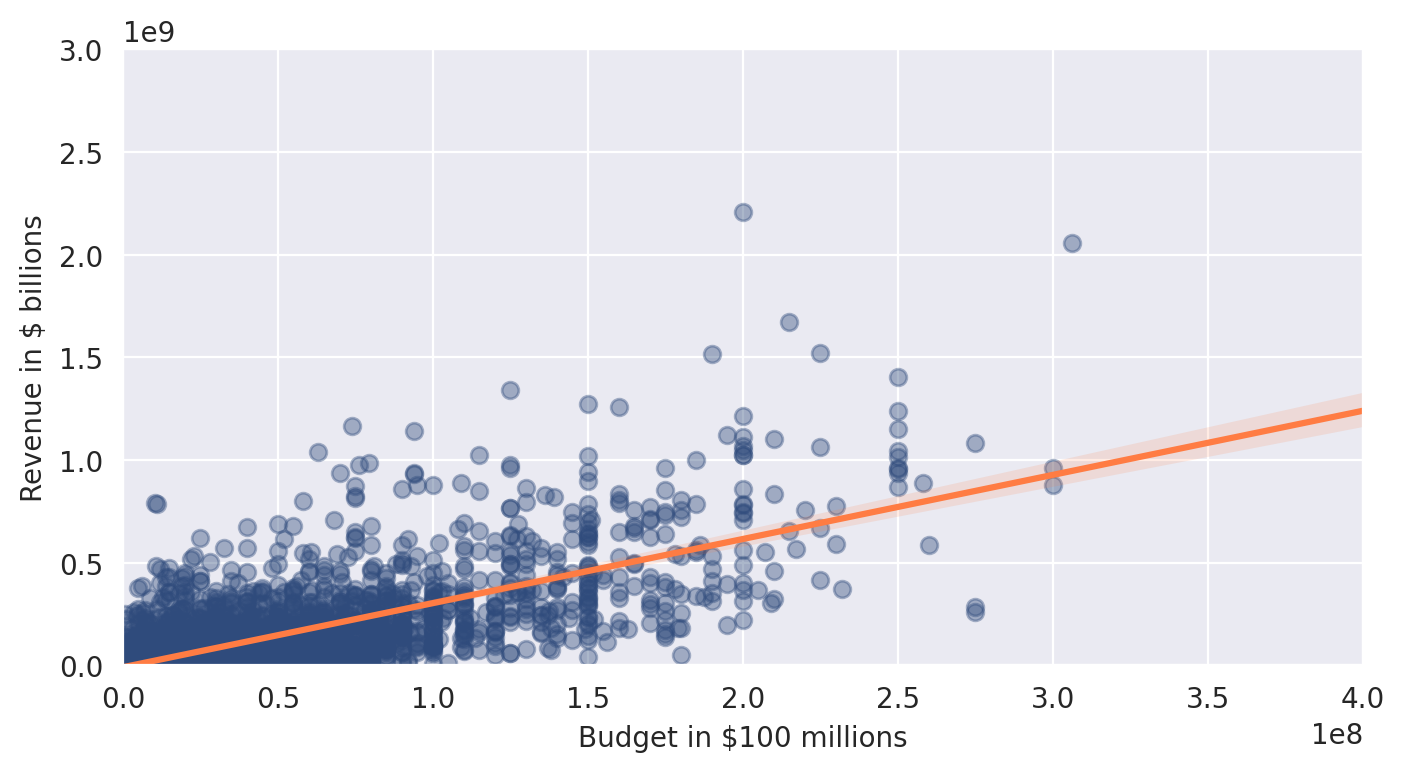

In [55]:
plt.figure(figsize=(8,4),dpi=200)
with sns.axes_style('darkgrid'):
  ax=sns.regplot(data=new_films,
                 x='USD_Production_Budget',
                 y='USD_Worldwide_Gross',
                 scatter_kws={'alpha':0.4,
                              'color':'#2f4b7c'},
                 line_kws={'color':'#ff7c43'})
  ax.set(ylim=(0,3000000000),
         xlim=(0,400000000),
         xlabel='Budget in $100 millions',
         ylabel='Revenue in $ billions')
plt.show()


In [ ]:
#From  the above chart, it is evident that data points for the new films align worse with the linear regression than for older ones
#A film with a budget of $150 million would make slightly under $500 million

# Run Your Own Regression with scikit-learn

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

In [60]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
X=pd.DataFrame(new_films,columns=['USD_Production_Budget']) #Explanatory variables(s) or features(s)
y=pd.DataFrame(new_films,columns=['USD_Worldwide_Gross']) #Response variable/target
regression.fit(X,y)

#Theta-0
regression.intercept_



array([-8650768.00661027])

In [62]:
#Theta-1
regression.coef_

array([[3.12259592]])

In [63]:
#R squared
regression.score(X,y) #Measures how well our model fits the data

0.5577032617720403

This means that our model explains about 56% of the variance in movie revenue

**Challenge**: Run a linear regression for the `old_films`. Calculate the intercept, slope and r-squared. How much of the variance in movie revenue does the linear model explain in this case?

In [64]:
X=pd.DataFrame(old_films,columns=['USD_Production_Budget'])
y=pd.DataFrame(old_films,columns=['USD_Worldwide_Gross'])
regression.fit(X,y)
print(f"Theta-0 (intercept): {regression.intercept_}")
print(f"Theta-1 (slope): {regression.coef_}")
print(f"R-squared: {regression.score(X,y)}")


Theta-0 (intercept): [22821538.63508039]
Theta-1 (slope): [[1.64771314]]
R-squared: 0.02937258620576877


In [ ]:
#The linear model explains only around 3% of the variance in movie revenue

# Use Your Model to Make a Prediction

We just estimated the slope and intercept! Remember that our Linear Model has the following form:

$$ REV \hat ENUE = \theta _0 + \theta _1 BUDGET$$

**Challenge**:  How much global revenue does our model estimate for a film with a budget of $350 million?

In [69]:
BUDGET=350000000
revenue_estimate=regression.intercept_[0]+(regression.coef_[0,0]*BUDGET)
print(f"The model estimates a global revenue of ${revenue_estimate:.10} for a film with a budget of $350 million")

The model estimates a global revenue of $599521139.0 for a film with a budget of $350 million
